# 07 - Park Clustering

## MLB Ballpark Effects on Pitch Type Frequency & Contact Quality

This notebook synthesizes all three analytical layers — pitch type frequency (notebook 04), 
swing outcomes (notebook 05), and contact quality (notebook 06) — into a unified park 
profile and clusters all 29 MLB parks into data-derived archetypes.

No park is pre-labeled as hitter or pitcher friendly. Archetypes emerge exclusively from 
the data. The number of clusters is determined by the elbow method, with hierarchical 
clustering as a secondary validation.

*Sample*: 29 MLB parks (2023–2025 pooled feature vectors)
<br>
*Features*: Pitch type frequencies, whiff and foul rates by pitch type, SOV deviations by pitch type
<br>
*Method*: K-means clustering (elbow method) + hierarchical validation

___
## 1) Setup & Data Load

In [ ]:
# Imports (more packages for this notebook) and Data Load

import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy import stats

#  Database connect
DB_PATH = Path(r"C:\Users\Bryce Gelarden\OneDrive - Indiana University\Documents\Github - brycemgelarden\MLB_Ballpark_Factor_Analysis\database\mlb_ballpark_effects.db")

conn = sqlite3.connect(DB_PATH)
df = pd.read_sql_query("SELECT * FROM swings", conn)
conn.close()

#  SOV-eligible sample 
df_sov = df[df["sov"].notna()].copy()

# Color scheme (project-wide) 
COLORS = {
    "Fastball":  "#1F4E79",
    "Breaking":  "#2E75B6",
    "Offspeed":  "#9DC3E6",
    "reference": "#9DC3E6",
}

In [2]:
# Validate

n_total = len(df)
n_sov   = len(df_sov)
n_parks = df["home_team"].nunique()

print(f"Total swings loaded:       {n_total:,}")
print(f"SOV-eligible observations: {n_sov:,}")
print(f"Parks confirmed:           {n_parks}")
print(f"\nParks:\n{sorted(df['home_team'].unique())}")

Total swings loaded:       173,137
SOV-eligible observations: 63,720
Parks confirmed:           29

Parks:
['ATL', 'AZ', 'BAL', 'BOS', 'CHC', 'CIN', 'CLE', 'COL', 'CWS', 'DET', 'HOU', 'KC', 'LAA', 'LAD', 'MIA', 'MIL', 'MIN', 'NYM', 'NYY', 'PHI', 'PIT', 'SD', 'SEA', 'SF', 'STL', 'TB', 'TEX', 'TOR', 'WSH']


___
## 2) Feature Engineering (Build Park Profile Matrix)

3 Layers
- Pitch Type Freq. per Park
- Swing Outcome per Park per Pitch Type
- SOV Deviation from league baseline per Park per Pitch Type

In [3]:
# Layer 1

park_counts = (
    df.groupby(["home_team", "pitch_category"])
    .size()
    .unstack(fill_value=0)
    [["Fastball", "Breaking", "Offspeed"]]
)
park_props = park_counts.div(park_counts.sum(axis=1), axis=0)
park_props.columns = ["freq_fastball", "freq_breaking", "freq_offspeed"]

print("Layer 1 — Pitch Frequency Features\n")
print(park_props.round(4).to_string())

Layer 1 — Pitch Frequency Features

           freq_fastball  freq_breaking  freq_offspeed
home_team                                             
ATL               0.5245         0.3422         0.1333
AZ                0.5547         0.2944         0.1509
BAL               0.5595         0.2718         0.1687
BOS               0.5688         0.2950         0.1362
CHC               0.5734         0.2954         0.1311
CIN               0.5619         0.2911         0.1470
CLE               0.5566         0.2866         0.1568
COL               0.5375         0.3243         0.1381
CWS               0.5552         0.3122         0.1326
DET               0.5410         0.2912         0.1678
HOU               0.5460         0.3284         0.1256
KC                0.5227         0.3267         0.1506
LAA               0.5394         0.2911         0.1694
LAD               0.5568         0.3166         0.1266
MIA               0.5418         0.3099         0.1482
MIL               0.6210     

In [4]:
# Layer 2

park_outcome_features = {}

for cat in ["Fastball", "Breaking", "Offspeed"]:
    cat_df = df[df["pitch_category"] == cat]
    rates = (
        cat_df.groupby(["home_team", "swing_outcome"])
        .size()
        .unstack(fill_value=0)
        [["whiff", "foul"]]
    )
    rates = rates.div(rates.sum(axis=1), axis=0)
    rates.columns = [f"whiff_{cat.lower()}", f"foul_{cat.lower()}"]
    park_outcome_features[cat] = rates

outcome_features = pd.concat(park_outcome_features.values(), axis=1)

print("Layer 2 — Swing Outcome Features\n")
print(outcome_features.round(4).to_string())

Layer 2 — Swing Outcome Features

           whiff_fastball  foul_fastball  whiff_breaking  foul_breaking  whiff_offspeed  foul_offspeed
home_team                                                                                             
ATL                0.3385         0.6615          0.5461         0.4539          0.4741         0.5259
AZ                 0.2976         0.7024          0.5073         0.4927          0.5304         0.4696
BAL                0.3221         0.6779          0.5019         0.4981          0.4887         0.5113
BOS                0.3022         0.6978          0.5030         0.4970          0.4810         0.5190
CHC                0.2876         0.7124          0.5118         0.4882          0.5476         0.4524
CIN                0.3176         0.6824          0.5022         0.4978          0.5019         0.4981
CLE                0.2982         0.7018          0.4682         0.5318          0.4594         0.5406
COL                0.3024         0.697

In [5]:
# Layer 3

league_sov_by_cat = (
    df_sov.groupby("pitch_category")["sov"]
    .mean()
)

sov_features = {}
for cat in ["Fastball", "Breaking", "Offspeed"]:
    park_means = (
        df_sov[df_sov["pitch_category"] == cat]
        .groupby("home_team")["sov"]
        .mean()
    )
    sov_features[f"sov_{cat.lower()}"] = park_means - league_sov_by_cat[cat]

sov_features = pd.DataFrame(sov_features)

print("Layer 3 — SOV Deviation Features\n")
print(sov_features.round(4).to_string())

Layer 3 — SOV Deviation Features

           sov_fastball  sov_breaking  sov_offspeed
home_team                                          
ATL              0.0275       -0.0197        0.0172
AZ               0.0011       -0.0242       -0.0563
BAL              0.0233        0.0257        0.0300
BOS             -0.0168       -0.0026       -0.0379
CHC             -0.0066       -0.0540       -0.0317
CIN             -0.0072       -0.0118        0.0013
CLE             -0.0030       -0.0088       -0.0122
COL              0.0196        0.0383        0.0425
CWS             -0.0201       -0.0070        0.0101
DET              0.0381        0.0075       -0.0081
HOU              0.0157       -0.0123        0.0490
KC              -0.0140        0.0494        0.0034
LAA             -0.0023        0.0118        0.0008
LAD              0.0222        0.0067        0.0180
MIA             -0.0100        0.0270       -0.0427
MIL             -0.0201        0.0002       -0.1168
MIN             -0.0080       

In [6]:
# combine all three layers into a single 29-row feature matrix
park_features = pd.concat([
    park_props,
    outcome_features,
    sov_features,
], axis=1)

print(f"Park Feature Matrix — {park_features.shape[0]} parks × {park_features.shape[1]} features\n")
print(park_features.round(4).to_string())
print(f"\nAny nulls: {park_features.isnull().sum().sum()}")

Park Feature Matrix — 29 parks × 12 features

           freq_fastball  freq_breaking  freq_offspeed  whiff_fastball  foul_fastball  whiff_breaking  foul_breaking  whiff_offspeed  foul_offspeed  sov_fastball  sov_breaking  sov_offspeed
home_team                                                                                                                                                                                    
ATL               0.5245         0.3422         0.1333          0.3385         0.6615          0.5461         0.4539          0.4741         0.5259        0.0275       -0.0197        0.0172
AZ                0.5547         0.2944         0.1509          0.2976         0.7024          0.5073         0.4927          0.5304         0.4696        0.0011       -0.0242       -0.0563
BAL               0.5595         0.2718         0.1687          0.3221         0.6779          0.5019         0.4981          0.4887         0.5113        0.0233        0.0257        0.0300
BOS 

___
## 3) Feature Scaling

Standardizes all 12 features (from the Section 3 matrix) to the same unit; zero mean and unit variance.  No single feature dominates the clustering due to magnitude when raw.

We will have two code cells:
- Use Python's `StandardScaler` package
- Verify the mean of all features is 0, and standard deviation is equal

In [7]:
# Scale Features (12)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
park_features_scaled = scaler.fit_transform(park_features)

park_features_scaled = pd.DataFrame(
    park_features_scaled,
    index=park_features.index,
    columns=park_features.columns,
)

print("Scaled Park Feature Matrix (Z-scores)\n")
print(park_features_scaled.round(4).to_string())

Scaled Park Feature Matrix (Z-scores)

           freq_fastball  freq_breaking  freq_offspeed  whiff_fastball  foul_fastball  whiff_breaking  foul_breaking  whiff_offspeed  foul_offspeed  sov_fastball  sov_breaking  sov_offspeed
home_team                                                                                                                                                                                    
ATL              -1.6891         2.1230        -0.6505          0.7027        -0.7027          2.1578        -2.1578         -1.0515         1.0515        1.4584       -0.8633        0.3886
AZ               -0.1876        -0.1914         0.5060         -1.1097         1.1097          0.3258        -0.3258          0.8838        -0.8838        0.0466       -1.0652       -1.3643
BAL               0.0517        -1.2847         1.6710         -0.0228         0.0228          0.0728        -0.0728         -0.5509         0.5509        1.2346        1.1640        0.6960
BOS        

In [8]:
# Confirm w/ needed conditions

print("Post-Scaling Verification\n")
print(f"{'Feature':<20} {'Mean':>10} {'Std':>10}")
print("-" * 42)
for col in park_features_scaled.columns:
    print(f"{col:<20} {park_features_scaled[col].mean():>10.4f} {park_features_scaled[col].std():>10.4f}")

Post-Scaling Verification

Feature                    Mean        Std
------------------------------------------
freq_fastball            0.0000     1.0177
freq_breaking           -0.0000     1.0177
freq_offspeed            0.0000     1.0177
whiff_fastball           0.0000     1.0177
foul_fastball           -0.0000     1.0177
whiff_breaking           0.0000     1.0177
foul_breaking            0.0000     1.0177
whiff_offspeed          -0.0000     1.0177
foul_offspeed            0.0000     1.0177
sov_fastball            -0.0000     1.0177
sov_breaking             0.0000     1.0177
sov_offspeed            -0.0000     1.0177


All good.

___
## 4) Elbow Method (Determine Optimal K)

**Inertia** — measures compactness within clusters; we look for the point where 
additional clusters stop meaningfully reducing inertia (the elbow).

**Silhouette Score** — measures separation between clusters; we look for the K 
where parks are most clearly distinct from neighboring clusters (the peak).

**Together** — where the elbow bends and silhouette peaks is the data's verdict on optimal K.

In [9]:
from sklearn.cluster import KMeans

RANDOM_STATE = 2005 

inertias = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    kmeans.fit(park_features_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(park_features_scaled, kmeans.labels_))

print("K    Inertia    Silhouette")
print("-" * 30)
for k, inertia, sil in zip(K_range, inertias, silhouette_scores):
    print(f"{k:<5}{inertia:>10.3f}    {sil:.4f}")

K    Inertia    Silhouette
------------------------------
2       285.087    0.1350
3       242.917    0.1323
4       212.366    0.1253
5       190.783    0.1450
6       180.140    0.0975
7       155.127    0.1325
8       138.916    0.1278
9       123.852    0.0924
10      109.095    0.1320


Visualizing these table'd numbers will make it much easier...

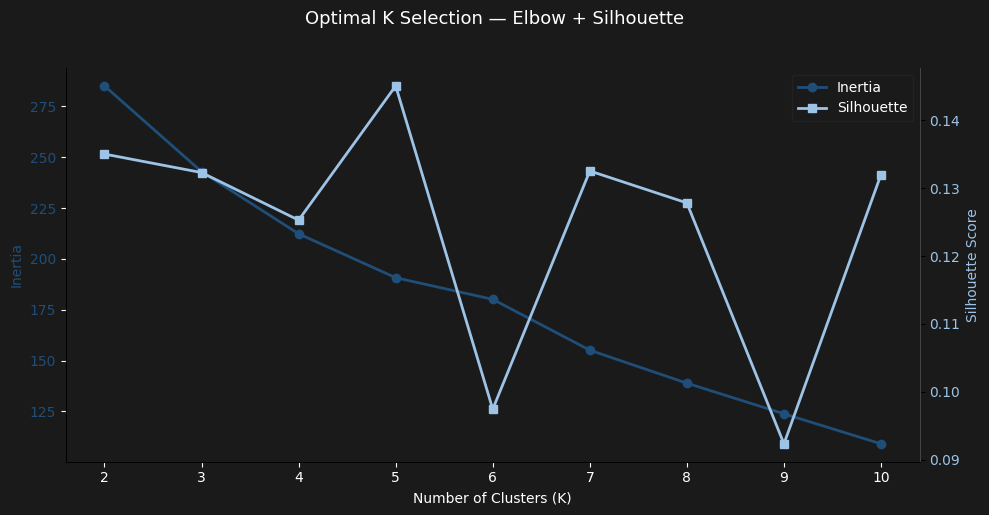

In [11]:
fig, ax1 = plt.subplots(figsize=(10, 5))

# inertia for left axis
ax1.plot(K_range, inertias, color=COLORS["Fastball"],
         linewidth=2, marker="o", markersize=6, label="Inertia")
ax1.set_xlabel("Number of Clusters (K)", color="white")
ax1.set_ylabel("Inertia", color=COLORS["Fastball"])
ax1.tick_params(colors="white")
ax1.tick_params(axis="y", labelcolor=COLORS["Fastball"])

# silhouette for right axis
ax2 = ax1.twinx()
ax2.plot(K_range, silhouette_scores, color=COLORS["Offspeed"],
         linewidth=2, marker="s", markersize=6, label="Silhouette")
ax2.set_ylabel("Silhouette Score", color=COLORS["Offspeed"])
ax2.tick_params(axis="y", labelcolor=COLORS["Offspeed"])

#legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2,
           framealpha=0.2, labelcolor="white",
           facecolor="#1a1a1a", edgecolor="#444444",
           loc="upper right")

ax1.set_facecolor("#1a1a1a")
fig.patch.set_facecolor("#1a1a1a")
ax1.spines[["top"]].set_visible(False)
ax1.spines[["bottom", "left"]].set_color("#444444")
ax2.spines[["top"]].set_visible(False)
ax2.spines[["right"]].set_color("#444444")

fig.suptitle("Optimal K Selection — Elbow + Silhouette",
             color="white", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

We go with **K = 5** because both metrics are in agreement.  Inertia curve bend is hazy, but most sharply at K = 5 (6th cluster would not meaningfully reduce within-cluster variance) and silhouette peaks at K = 5 (cluster separation is strongest at that value).

___
## 5) K-Means Clustering

In [31]:
OPTIMAL_K = 5

kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=RANDOM_STATE, n_init=10)
kmeans.fit(park_features_scaled)

# assign cluster labels to each park
park_features["cluster"] = kmeans.labels_
park_features_scaled["cluster"] = kmeans.labels_

print(f"K-Means Clustering Complete — K = {OPTIMAL_K}\n")
print("Park Cluster Assignments:\n")
for cluster in sorted(park_features["cluster"].unique()):
    parks = park_features[park_features["cluster"] == cluster].index.tolist()
    print(f"Cluster {cluster}: {parks}")

K-Means Clustering Complete — K = 5

Park Cluster Assignments:

Cluster 0: ['HOU', 'LAA', 'NYM', 'NYY', 'SEA']
Cluster 1: ['BOS', 'CLE', 'MIL', 'SD', 'STL', 'WSH']
Cluster 2: ['AZ', 'CHC', 'CIN', 'CWS', 'MIA', 'PHI', 'SF']
Cluster 3: ['ATL', 'COL', 'DET', 'KC', 'LAD', 'PIT']
Cluster 4: ['BAL', 'MIN', 'TB', 'TEX', 'TOR']


In [32]:
# mean feature values per cluster — reveals what defines each archetype
cluster_profiles = (
    park_features.groupby("cluster")
    .mean()
    .round(4)
)

print("Cluster Profiles — Mean Feature Values\n")
print(cluster_profiles.to_string())

Cluster Profiles — Mean Feature Values

         freq_fastball  freq_breaking  freq_offspeed  whiff_fastball  foul_fastball  whiff_breaking  foul_breaking  whiff_offspeed  foul_offspeed  sov_fastball  sov_breaking  sov_offspeed
cluster                                                                                                                                                                                    
0               0.5606         0.2953         0.1441          0.3469         0.6531          0.5119         0.4881          0.5445         0.4555        0.0039        0.0006        0.0202
1               0.5770         0.2901         0.1330          0.3047         0.6953          0.4857         0.5143          0.4831         0.5169       -0.0178       -0.0101       -0.0291
2               0.5544         0.3015         0.1440          0.3154         0.6846          0.5006         0.4994          0.5167         0.4833       -0.0058       -0.0120       -0.0173
3               0.53

A PCA projection was first attempted to visualize cluster separation in 2D space. 
PCA preserves maximum variance but compresses 12 dimensions into 2 — only 48.6% 
of total variance is captured, meaning cluster separation may be stronger in full 
12D space than this projection suggests.

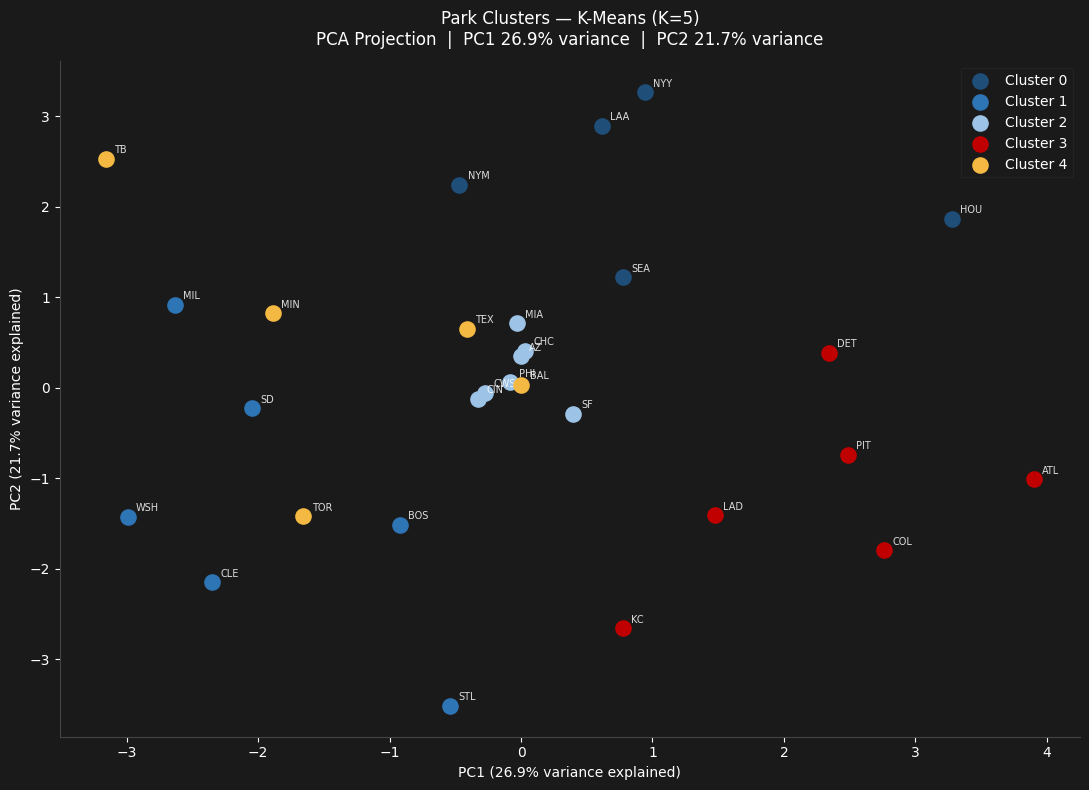

In [ ]:
from sklearn.decomposition import PCA

# reduce to 2D for visualization — PCA preserves maximum variance
pca = PCA(n_components=2, random_state=RANDOM_STATE)
coords = pca.fit_transform(park_features_scaled.drop("cluster", axis=1))

explained = pca.explained_variance_ratio_ * 100

CLUSTER_COLORS = {
    0: "#1F4E79",
    1: "#2E75B6",
    2: "#9DC3E6",
    3: "#C00000",
    4: "#F4B942",
}

fig, ax = plt.subplots(figsize=(11, 8))

for cluster in sorted(park_features["cluster"].unique()):
    mask = park_features["cluster"] == cluster
    ax.scatter(
        coords[mask, 0],
        coords[mask, 1],
        color=CLUSTER_COLORS[cluster],
        s=120,
        label=f"Cluster {cluster}",
        zorder=3,
    )
    # label parks
    for i, park in enumerate(park_features[mask].index):
        ax.annotate(
            park,
            (coords[mask, 0][i], coords[mask, 1][i]),
            textcoords="offset points",
            xytext=(6, 4),
            fontsize=7,
            color="white",
            alpha=0.85,
        )

ax.set_title(
    f"Park Clusters — K-Means (K=5)\nPCA Projection  |  PC1 {explained[0]:.1f}% variance  |  PC2 {explained[1]:.1f}% variance",
    color="white", fontsize=12, pad=12
)
ax.set_xlabel(f"PC1 ({explained[0]:.1f}% variance explained)", color="white")
ax.set_ylabel(f"PC2 ({explained[1]:.1f}% variance explained)", color="white")
ax.tick_params(colors="white")
ax.set_facecolor("#1a1a1a")
fig.patch.set_facecolor("#1a1a1a")
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["bottom", "left"]].set_color("#444444")
ax.legend(
    framealpha=0.2, labelcolor="white",
    facecolor="#1a1a1a", edgecolor="#444444"
)

plt.tight_layout()
plt.show()

Cluster separation is not visually clean in the PCA projection. Parks within the 
same cluster are not consistently grouped, which is expected given the information 
loss in dimensionality reduction. Radar and parallel coordinates plots were also 
evaluated and faced similar readability issues with 29 parks across 12 features.

The heatmap below provides the most readable representation of park feature profiles 
— sorting parks by cluster assignment and coloring by Z-score makes both individual 
park identities and cluster-level patterns immediately visible.

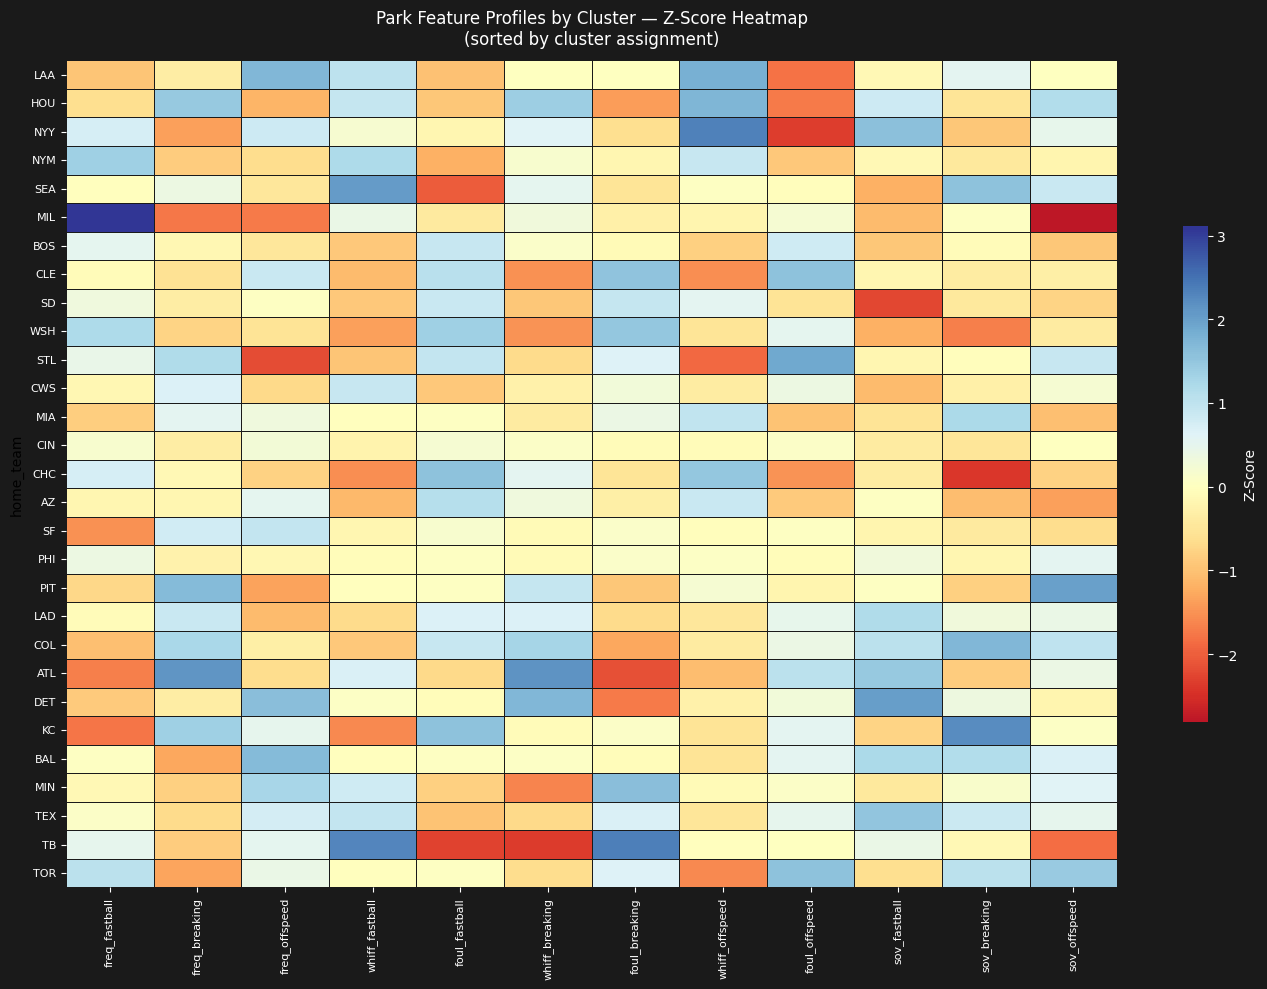

In [34]:
# sort parks by cluster for readability
heatmap_data = park_features_scaled.drop("cluster", axis=1).copy()
heatmap_data["cluster"] = park_features["cluster"]
heatmap_data = heatmap_data.sort_values("cluster").drop("cluster", axis=1)

# cluster color bar labels
cluster_labels = park_features["cluster"].sort_values().values

fig, ax = plt.subplots(figsize=(14, 10))

sns.heatmap(
    heatmap_data,
    ax=ax,
    cmap="RdYlBu",
    center=0,
    linewidths=0.5,
    linecolor="#1a1a1a",
    cbar_kws={"label": "Z-Score", "shrink": 0.6},
)

ax.set_title("Park Feature Profiles by Cluster — Z-Score Heatmap\n(sorted by cluster assignment)",
             color="white", fontsize=12, pad=12)
ax.tick_params(colors="white", labelsize=8)
ax.set_facecolor("#1a1a1a")
fig.patch.set_facecolor("#1a1a1a")
fig.axes[-1].tick_params(colors="white")
fig.axes[-1].yaxis.label.set_color("white")

plt.tight_layout()
plt.show()

MIL's deep blue on `freq_fastball` and deep red on `sov_offspeed` is the most 
visually striking signal in the entire heatmap — consistent with every finding 
across notebooks 04, 05, and 06. Section 7 formalizes what each cluster represents 
as a named park archetype.

___
## 6) Hierarchal Clustering (Validation)

In [35]:
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering

# fit hierarchical clustering with same K for direct comparison to k-means
hierarchical = AgglomerativeClustering(n_clusters=OPTIMAL_K, linkage="ward")
hier_labels = hierarchical.fit_predict(park_features_scaled.drop("cluster", axis=1))

# assign to dataframe
park_features["hier_cluster"] = hier_labels

print("Hierarchical Cluster Assignments (Ward Linkage, K=5)\n")
for cluster in sorted(set(hier_labels)):
    parks = park_features[park_features["hier_cluster"] == cluster].index.tolist()
    print(f"Cluster {cluster}: {parks}")

Hierarchical Cluster Assignments (Ward Linkage, K=5)

Cluster 0: ['AZ', 'BOS', 'CHC', 'CIN', 'MIL', 'NYY', 'PHI', 'SD', 'WSH']
Cluster 1: ['BAL', 'CLE', 'MIN', 'TB', 'TEX', 'TOR']
Cluster 2: ['ATL', 'DET', 'HOU', 'PIT']
Cluster 3: ['CWS', 'LAA', 'MIA', 'NYM', 'SEA', 'SF']
Cluster 4: ['COL', 'KC', 'LAD', 'STL']


In [36]:
# side by side comparison — where do they agree and disagree?
comparison = pd.DataFrame({
    "kmeans":      park_features["cluster"],
    "hierarchical": park_features["hier_cluster"],
}, index=park_features.index).sort_values("kmeans")

# flag parks where assignments differ
comparison["agreement"] = comparison["kmeans"] == comparison["hierarchical"]

print("K-Means vs Hierarchical Cluster Comparison\n")
print(comparison.to_string())
print(f"\nParks in agreement: {comparison['agreement'].sum()} of 29")
print(f"Parks that differ:  {(~comparison['agreement']).sum()} of 29")
print(f"\nDisagreements:")
print(comparison[~comparison["agreement"]].to_string())

K-Means vs Hierarchical Cluster Comparison

           kmeans  hierarchical  agreement
home_team                                 
LAA             0             3      False
HOU             0             2      False
NYY             0             0       True
NYM             0             3      False
SEA             0             3      False
MIL             1             0      False
BOS             1             0      False
CLE             1             1       True
SD              1             0      False
WSH             1             0      False
STL             1             4      False
CWS             2             3      False
MIA             2             3      False
CIN             2             0      False
CHC             2             0      False
AZ              2             0      False
SF              2             3      False
PHI             2             0      False
PIT             3             2      False
LAD             3             4      False
COL       

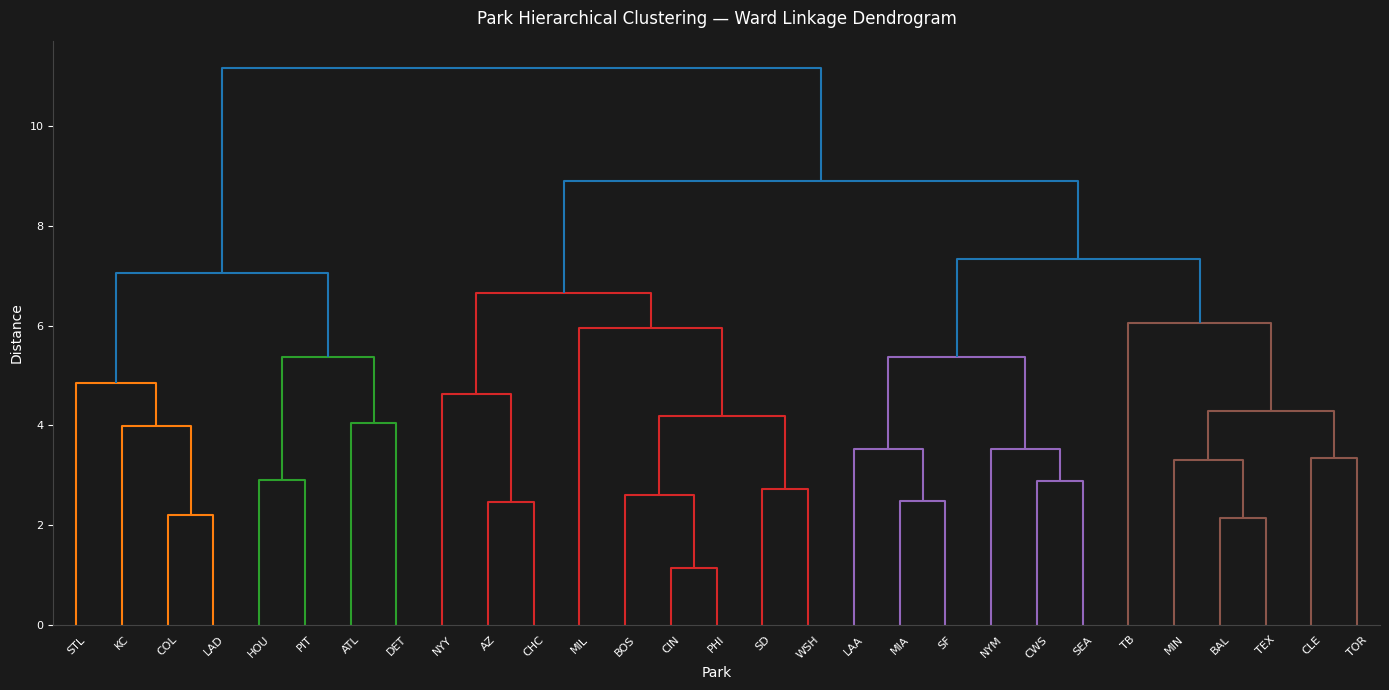

In [38]:
# dendrogram shows the full hierarchical merge structure
linked = linkage(
    park_features_scaled.drop(["cluster"], axis=1),
    method="ward"
)

fig, ax = plt.subplots(figsize=(14, 7))

dendrogram(
    linked,
    labels=park_features.index.tolist(),
    orientation="top",
    color_threshold=linked[-OPTIMAL_K+1, 2],
    ax=ax,
    leaf_font_size=9,
)

ax.set_title("Park Hierarchical Clustering — Ward Linkage Dendrogram",
             color="white", fontsize=12, pad=12)
ax.set_xlabel("Park", color="white")
ax.set_ylabel("Distance", color="white")
ax.tick_params(colors="white", labelsize=8)
ax.set_facecolor("#1a1a1a")
fig.patch.set_facecolor("#1a1a1a")
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["bottom", "left"]].set_color("#444444")

plt.tight_layout()
plt.show()

Hierarchical clustering (Ward linkage, K=5) produces only 2 of 29 park assignments 
in agreement with K-means — a significant divergence that warrants honest acknowledgment.

This does not invalidate either method. With 29 parks across 12 features, both 
algorithms are sensitive to small distributional differences and the "correct" 
clustering structure is genuinely ambiguous at this sample size. What the disagreement 
tells us is that the park archetypes emerging from this data are not mathematically 
obvious — they are interpretive.

The dendrogram is the more trustworthy visualization here. Without forcing K=5, the 
natural hierarchy shows a clear high-level split between two broad park families, 
which K=5 then subdivides. The big structural divide in the dendrogram — not the 
specific cluster assignments — is the finding worth carrying into Section 7.

**Section 7 archetype labeling is treated as descriptive and exploratory, not 
statistically definitive.** The goal is not to declare five clean park types — it 
is to characterize what the data suggests about park personalities given everything 
notebooks 04, 05, and 06 established.

___
## 7) Cluster Profiles & Archetype Labeling

In [39]:
ARCHETYPE_LABELS = {
    0: "Swing & Miss",
    1: "Contact Suppression",
    2: "Neutral",
    3: "High Contact Quality",
    4: "Mixed Profile",
}

ARCHETYPE_COLORS = {
    0: "#C00000",
    1: "#1F4E79",
    2: "#9DC3E6",
    3: "#F4B942",
    4: "#2E75B6",
}

park_features["archetype"] = park_features["cluster"].map(ARCHETYPE_LABELS)

print("Park Archetype Assignments\n")
for archetype in ARCHETYPE_LABELS.values():
    parks = park_features[park_features["archetype"] == archetype].index.tolist()
    print(f"{archetype}:\n  {parks}\n")

Park Archetype Assignments

Swing & Miss:
  ['HOU', 'LAA', 'NYM', 'NYY', 'SEA']

Contact Suppression:
  ['BOS', 'CLE', 'MIL', 'SD', 'STL', 'WSH']

Neutral:
  ['AZ', 'CHC', 'CIN', 'CWS', 'MIA', 'PHI', 'SF']

High Contact Quality:
  ['ATL', 'COL', 'DET', 'KC', 'LAD', 'PIT']

Mixed Profile:
  ['BAL', 'MIN', 'TB', 'TEX', 'TOR']



In [40]:
archetype_profiles = (
    park_features.groupby("archetype")
    .mean()
    .drop(["cluster", "hier_cluster"], axis=1)
    .round(4)
)

print("Archetype Mean Feature Profiles\n")
print(archetype_profiles.to_string())

Archetype Mean Feature Profiles

                      freq_fastball  freq_breaking  freq_offspeed  whiff_fastball  foul_fastball  whiff_breaking  foul_breaking  whiff_offspeed  foul_offspeed  sov_fastball  sov_breaking  sov_offspeed
archetype                                                                                                                                                                                               
Contact Suppression          0.5770         0.2901         0.1330          0.3047         0.6953          0.4857         0.5143          0.4831         0.5169       -0.0178       -0.0101       -0.0291
High Contact Quality         0.5378         0.3223         0.1399          0.3136         0.6864          0.5240         0.4760          0.4924         0.5076        0.0157        0.0106        0.0263
Mixed Profile                0.5646         0.2780         0.1574          0.3409         0.6591          0.4781         0.5219          0.4887         0.5113     

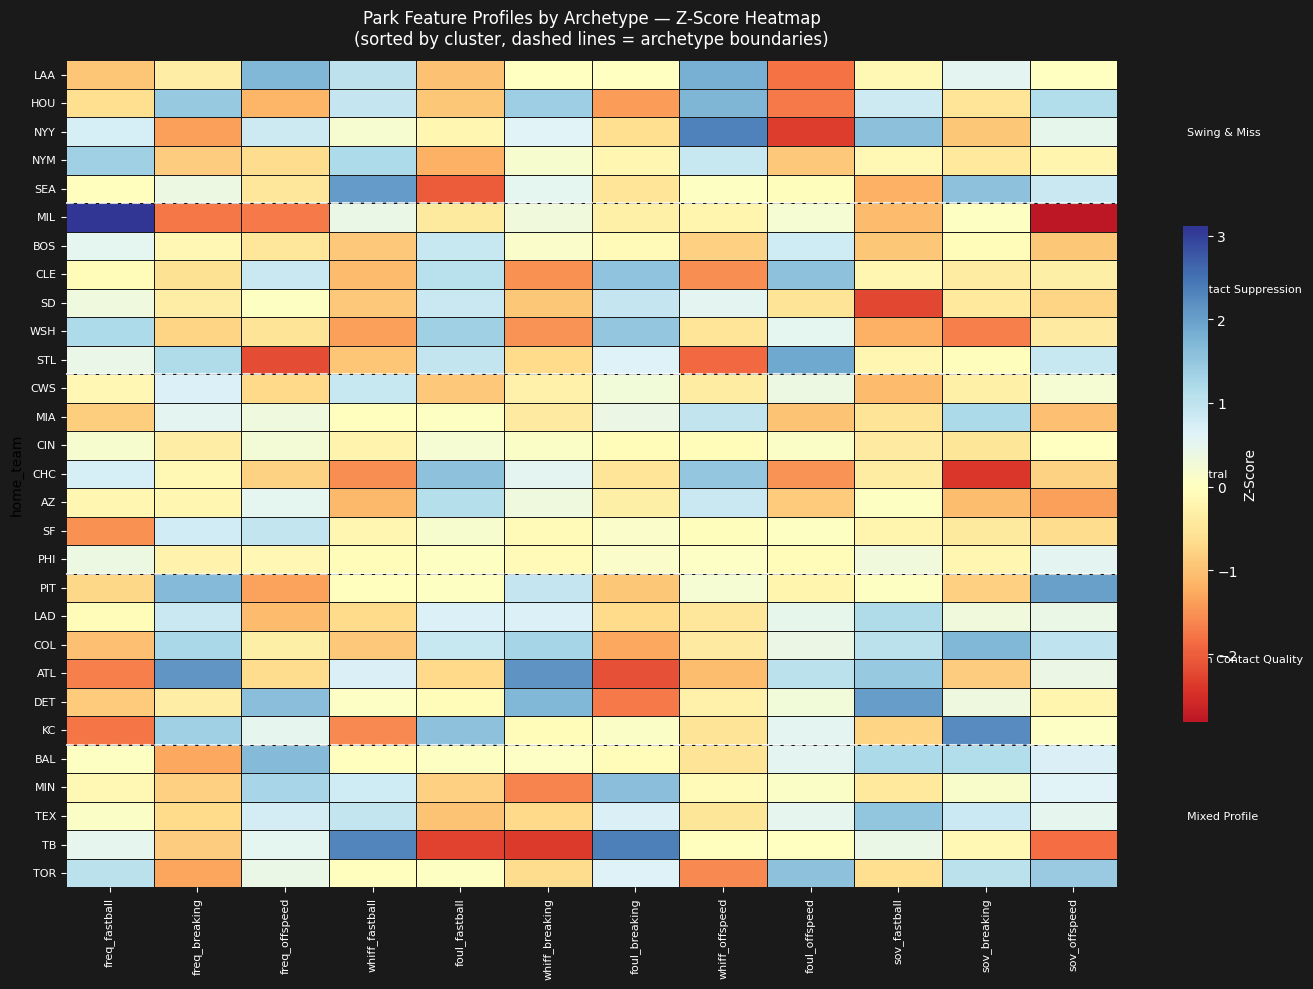

In [41]:
# sort by archetype for clean cluster boundaries
heatmap_data = park_features.copy()
heatmap_data = heatmap_data.sort_values("cluster")

feature_cols = [c for c in park_features_scaled.columns if c != "cluster"]
heatmap_scaled = park_features_scaled[feature_cols].loc[heatmap_data.index]

# cluster boundary positions
cluster_sizes = heatmap_data.groupby("cluster").size().sort_index()
boundaries = cluster_sizes.cumsum().values[:-1]

fig, ax = plt.subplots(figsize=(14, 10))

sns.heatmap(
    heatmap_scaled,
    ax=ax,
    cmap="RdYlBu",
    center=0,
    linewidths=0.5,
    linecolor="#1a1a1a",
    cbar_kws={"label": "Z-Score", "shrink": 0.6},
)

# add cluster boundary lines
for boundary in boundaries:
    ax.axhline(boundary, color="white", linewidth=1.5, linestyle="--", alpha=0.8)

# add archetype labels on right side
cumulative = 0
for cluster in sorted(heatmap_data["cluster"].unique()):
    size = cluster_sizes[cluster]
    midpoint = cumulative + size / 2
    archetype = ARCHETYPE_LABELS[cluster]
    ax.text(
        12.8, midpoint,
        archetype,
        color="white",
        fontsize=8,
        va="center",
        ha="left",
    )
    cumulative += size

ax.set_title(
    "Park Feature Profiles by Archetype — Z-Score Heatmap\n(sorted by cluster, dashed lines = archetype boundaries)",
    color="white", fontsize=12, pad=12
)
ax.tick_params(colors="white", labelsize=8)
ax.set_facecolor("#1a1a1a")
fig.patch.set_facecolor("#1a1a1a")
fig.axes[-1].tick_params(colors="white")
fig.axes[-1].yaxis.label.set_color("white")

plt.tight_layout()
plt.show()

In [42]:
archetype_summary = (
    park_features.groupby("archetype")
    .apply(lambda x: ", ".join(sorted(x.index.tolist())))
    .reset_index()
)
archetype_summary.columns = ["archetype", "parks"]
archetype_summary["n_parks"] = archetype_summary["parks"].apply(lambda x: len(x.split(", ")))

print("Final Park Archetype Summary\n")
print(archetype_summary.to_string(index=False))


Final Park Archetype Summary

           archetype                           parks  n_parks
 Contact Suppression     BOS, CLE, MIL, SD, STL, WSH        6
High Contact Quality     ATL, COL, DET, KC, LAD, PIT        6
       Mixed Profile          BAL, MIN, TB, TEX, TOR        5
             Neutral AZ, CHC, CIN, CWS, MIA, PHI, SF        7
        Swing & Miss         HOU, LAA, NYM, NYY, SEA        5
